# Segmentation Client par Machine Learning — E-Commerce
**Objectif** : Segmenter 446 clients en groupes homogènes via des algorithmes de clustering non supervisé appliqués sur des données RFM enrichies.

**Modèle final retenu** : Agglomerative Clustering n=5 — Silhouette : 0.751 | DB Index : 0.681

## Imports et Connexion

In [6]:
import pyodbc
import pandas as pd
from sqlalchemy import create_engine, text
import urllib
import numpy as np

# ── Paramètres de connexion ───────────────────────────────────
SERVER   = "KALLALA" 
DATABASE = "DW_E-Commerce"      

# ── Chaîne de connexion ───────────────────────────────────────
connection_string = (
    f"DRIVER={{ODBC Driver 17 for SQL Server}};"
    f"SERVER={SERVER};"
    f"DATABASE={DATABASE};"
    f"Trusted_Connection=yes;"
)

params = urllib.parse.quote_plus(connection_string)
engine = create_engine(f"mssql+pyodbc:///?odbc_connect={params}")

try:
    with engine.connect() as conn:
        print("Connexion réussie !")
        result = conn.execute(text("SELECT DB_NAME() AS base_active"))  
        print("Base active :", result.fetchone()[0])
except Exception as e:
    print("Erreur de connexion :", e)

Connexion réussie !
Base active : DW_E-Commerce


## Étape 1 — Chargement des données
On charge les 3 tables depuis SQL Server : `Fact_Ventes` (831 transactions), `Dim_Client` (464 clients), `DimDates` (table de dates).

In [7]:
df      = pd.read_sql('SELECT * FROM Fact_Ventes', engine)
clients = pd.read_sql('SELECT * FROM Dim_Client',  engine)
dates   = pd.read_sql('SELECT * FROM DimDates',    engine)

print(f'Fact_Ventes  : {df.shape}')
print(f'Dim_Client   : {clients.shape}')
print(f'DimDates     : {dates.shape}')

Fact_Ventes  : (831, 17)
Dim_Client   : (464, 6)
DimDates     : (36891, 17)


## Étape 2 — Merge des tables
Jointure des 3 tables pour obtenir un dataset complet par ligne de vente, avec type client et vraie date.

In [8]:
df_full = df.merge(clients, left_on='Client_FK', right_on='Client_PK', how='left')
df_full = df_full.merge(dates, left_on='Date_FK', right_on='Date_PK', how='left')
df_full['Date'] = pd.to_datetime(df_full['Date'])
today = df_full['Date'].max()
print(f'Dataset fusionné : {df_full.shape}')
print(f'Date de référence (today) : {today.date()}')

Dataset fusionné : (831, 40)
Date de référence (today) : 2026-01-02


## Étape 3 — Feature Engineering
Construction de 12 variables par client : **RFM** (Recency, Frequency, Monetary) + **8 features comportementales**.

La variable `Is_Entreprise` est la plus discriminante — elle sépare naturellement B2B et B2C.

In [10]:
rfm = df_full.groupby('Client_FK').agg(
    Recency   = ('Date',                   lambda x: (today - x.max()).days),
    Frequency = ('Numero_Commande',        'nunique'),
    Monetary  = ('Montant_de_la_commande', 'sum')
)

extra_features = df_full.groupby('Client_FK').agg(
    Avg_Basket           = ('Montant_de_la_commande', 'mean'),
    Total_Quantite       = ('Quantite',               'sum'),
    Nb_Produits          = ('Produit_FK',             'nunique'),
    Total_Remise         = ('Montant_Remise',         'sum'),
    Total_Remboursement  = ('Montant_Remboursement',  'sum'),
    Nb_Ventes            = ('Vente_PK',              'count'),
    Mode_Vente_Principal = ('Type_Vente_FK',          lambda x: x.mode()[0]),
)
extra_features['Taux_Remise'] = extra_features['Total_Remise'] / rfm['Monetary'].replace(0, 1)

dataset = rfm.merge(extra_features, on='Client_FK')

client_type = clients[['Client_PK', 'Type_client']].rename(columns={'Client_PK': 'Client_FK'})
dataset = dataset.merge(client_type, on='Client_FK', how='left')
dataset['Is_Entreprise'] = (dataset['Type_client'] == 'Entreprise').astype(int)
dataset = dataset.drop(columns=['Type_client'])
dataset = dataset.fillna(0)

print('Dataset shape:', dataset.shape)
print('\nValeurs manquantes :')
print(dataset.isnull().sum())
dataset.head()

Dataset shape: (446, 13)

Valeurs manquantes :
Client_FK               0
Recency                 0
Frequency               0
Monetary                0
Avg_Basket              0
Total_Quantite          0
Nb_Produits             0
Total_Remise            0
Total_Remboursement     0
Nb_Ventes               0
Mode_Vente_Principal    0
Taux_Remise             0
Is_Entreprise           0
dtype: int64


,Client_FK,Recency,Frequency,Monetary,Avg_Basket,Total_Quantite,Nb_Produits,Total_Remise,Total_Remboursement,Nb_Ventes,Mode_Vente_Principal,Taux_Remise,Is_Entreprise
0,5890,42,1,2439.0,101.6250,66,12,0.0,0.0,24,2,0.0,1
1,5891,46,1,54154.0,10830.8000,869,4,0.0,0.0,5,2,0.0,1
2,5892,18,1,36667.5,4583.4375,3850,8,0.0,0.0,8,2,0.0,1
3,5893,364,1,50000.0,50000.0000,500,1,0.0,0.0,1,2,0.0,1
4,5894,42,1,1056.0,88.0000,33,3,0.0,0.0,12,2,0.0,1


## Étape 3B — Détection des Outliers (Z-Score)
Un Z-Score > 3 signifie que la valeur est à plus de 3 écarts-types de la moyenne.
Les outliers détectés sont principalement les **grands comptes B2B** — on les conserve car ils sont légitimes et stratégiques.

In [11]:
features_to_scale = [
    'Recency', 'Frequency', 'Monetary',
    'Avg_Basket', 'Total_Quantite', 'Nb_Produits',
    'Total_Remise', 'Total_Remboursement',
    'Nb_Ventes', 'Mode_Vente_Principal',
    'Taux_Remise', 'Is_Entreprise'
]

z_scores = np.abs(stats.zscore(dataset[features_to_scale]))
outliers_mask = (z_scores > 3).any(axis=1)
print(f'Outliers détectés : {outliers_mask.sum()} clients ({outliers_mask.sum()/len(dataset)*100:.1f}%)')
print(f'Clients normaux   : {(~outliers_mask).sum()} clients')
print('\nProfil des outliers :')
print(dataset[outliers_mask][['Recency','Monetary','Avg_Basket','Is_Entreprise']].describe())

Outliers détectés : 39 clients (8.7%)
Clients normaux   : 407 clients

Profil des outliers :
          Recency       Monetary    Avg_Basket  Is_Entreprise
count   39.000000      39.000000     39.000000      39.000000
mean   315.974359    9856.277949   3066.715605       0.358974
std    315.315088   30011.091541   9229.579470       0.485971
min      8.000000       8.000000      8.000000       0.000000
25%     43.500000      74.000000     47.833333       0.000000
50%    233.000000     216.000000    101.625000       0.000000
75%    344.000000    1989.750000   1182.500000       1.000000
max    912.000000  174075.000000  50000.000000       1.000000


### Visualisation des Outliers — Recency vs Monetary

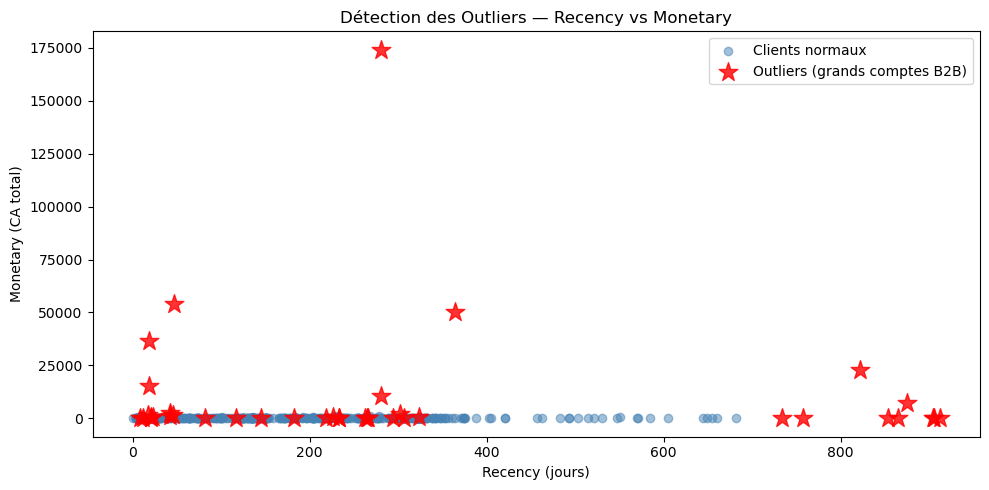

In [12]:
plt.figure(figsize=(10, 5))
plt.scatter(dataset.loc[~outliers_mask, 'Recency'],
            dataset.loc[~outliers_mask, 'Monetary'],
            alpha=0.5, label='Clients normaux', color='steelblue')
plt.scatter(dataset.loc[outliers_mask, 'Recency'],
            dataset.loc[outliers_mask, 'Monetary'],
            alpha=0.8, label='Outliers (grands comptes B2B)', color='red', marker='*', s=200)
plt.xlabel('Recency (jours)')
plt.ylabel('Monetary (CA total)')
plt.title('Détection des Outliers — Recency vs Monetary')
plt.legend()
plt.tight_layout()
plt.show()

## Étape 4 — Normalisation (StandardScaler) + PCA
StandardScaler ramène chaque feature à moyenne=0, écart-type=1.
La PCA réduit les 12 dimensions en 2 composantes pour la visualisation uniquement.

In [13]:
scaler = StandardScaler()
dataset_scaled = scaler.fit_transform(dataset[features_to_scale])

pca = PCA(n_components=2)
data_pca = pca.fit_transform(dataset_scaled)

print(f'PCA — Variance expliquée :')
print(f'  PCA1 : {pca.explained_variance_ratio_[0]*100:.1f}%')
print(f'  PCA2 : {pca.explained_variance_ratio_[1]*100:.1f}%')
print(f'  Total : {sum(pca.explained_variance_ratio_)*100:.1f}%')

all_results = {}

PCA — Variance expliquée :
  PCA1 : 33.2%
  PCA2 : 16.5%
  Total : 49.7%


## Étape 5 — Détermination du K optimal pour KMeans
### Méthode 1 : Elbow Method
On trace l'inertie (somme des distances au carré au centroïde) pour K=1 à 9. Le 'coude' indique le K optimal.

c:\Users\mehdi\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
c:\Users\mehdi\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
c:\Users\mehdi\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
c:\Users\mehdi\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Window

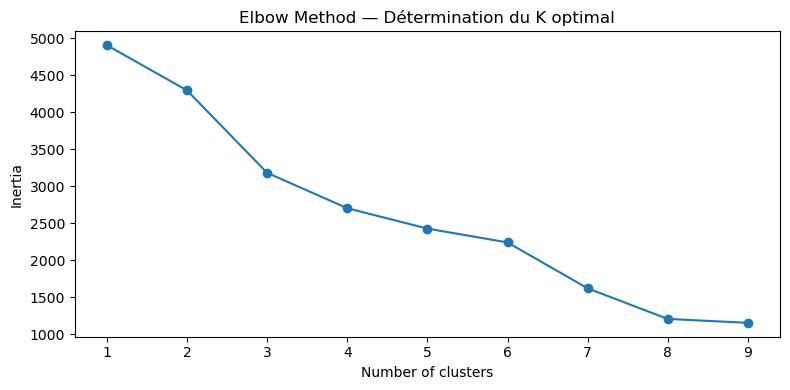

In [14]:
inertia = []
K = range(1, 10)
for k in K:
    model = KMeans(n_clusters=k, random_state=42)
    model.fit(dataset_scaled)
    inertia.append(model.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(K, inertia, marker='o')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.title('Elbow Method — Détermination du K optimal')
plt.tight_layout()
plt.show()

### Méthode 2 : Silhouette Score vs K
Le Silhouette Score mesure la qualité de séparation des clusters. Plus c'est proche de 1, mieux c'est.

**Résultat** : K=2 et K=3 sont les meilleurs statistiquement (~0.86) mais trop grossiers pour le marketing. K=5 à K=7 sont stables à ~0.47.

c:\Users\mehdi\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
c:\Users\mehdi\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
c:\Users\mehdi\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
c:\Users\mehdi\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Window

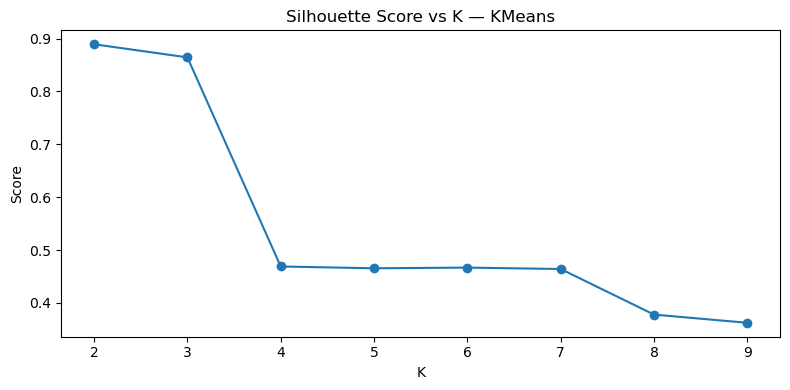

  K=2 → Silhouette: 0.8892
  K=3 → Silhouette: 0.8644
  K=4 → Silhouette: 0.4689
  K=5 → Silhouette: 0.4655
  K=6 → Silhouette: 0.4668
  K=7 → Silhouette: 0.4641
  K=8 → Silhouette: 0.3779
  K=9 → Silhouette: 0.3624


In [15]:
scores_kmeans = []
K_range = range(2, 10)
for k in K_range:
    model = KMeans(n_clusters=k, random_state=42)
    labels = model.fit_predict(dataset_scaled)
    scores_kmeans.append(silhouette_score(dataset_scaled, labels))

plt.figure(figsize=(8, 4))
plt.plot(K_range, scores_kmeans, marker='o')
plt.title('Silhouette Score vs K — KMeans')
plt.xlabel('K')
plt.ylabel('Score')
plt.tight_layout()
plt.show()

for k, s in zip(K_range, scores_kmeans):
    print(f'  K={k} → Silhouette: {s:.4f}')

In [16]:
best_km_sil, best_km_n, best_km_labels = -1, 0, None
for n in range(2, 10):
    km = KMeans(n_clusters=n, random_state=42, n_init=10)
    labels = km.fit_predict(dataset_scaled)
    sil = silhouette_score(dataset_scaled, labels)
    db  = davies_bouldin_score(dataset_scaled, labels)
    print(f'  n={n} | Silhouette: {sil:.4f} | DB Index: {db:.4f}')
    if sil > best_km_sil:
        best_km_sil, best_km_n, best_km_labels = sil, n, labels

print(f'\n✅ Meilleur KMeans automatique : n={best_km_n} (Silhouette={best_km_sil:.4f})')
dataset['KM_Cluster'] = best_km_labels
all_results[f'KMeans n={best_km_n} (auto)'] = {'sil': best_km_sil, 'db': None, 'n': best_km_n, 'b2b': True}

km_profile = dataset.groupby('KM_Cluster')[features_to_scale].mean()
print('\nKMeans Profiling (colonnes clés) :')
print(km_profile[['Recency','Monetary','Is_Entreprise','Taux_Remise']].to_string())

c:\Users\mehdi\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
c:\Users\mehdi\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
c:\Users\mehdi\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
c:\Users\mehdi\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Window

  n=2 | Silhouette: 0.8086 | DB Index: 0.9917
  n=3 | Silhouette: 0.7899 | DB Index: 0.8226
  n=4 | Silhouette: 0.7939 | DB Index: 0.6846
  n=5 | Silhouette: 0.2865 | DB Index: 1.1129


c:\Users\mehdi\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
c:\Users\mehdi\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
c:\Users\mehdi\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


  n=6 | Silhouette: 0.3317 | DB Index: 0.8848
  n=7 | Silhouette: 0.4501 | DB Index: 0.6634
  n=8 | Silhouette: 0.3779 | DB Index: 0.6639
  n=9 | Silhouette: 0.4075 | DB Index: 0.5606

✅ Meilleur KMeans automatique : n=2 (Silhouette=0.8086)

KMeans Profiling (colonnes clés) :
               Recency      Monetary  Is_Entreprise  Taux_Remise
KM_Cluster                                                      
0           209.770833    185.917778            0.0     0.038315
1           124.785714  24342.167143            1.0     0.000000


c:\Users\mehdi\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


ON NE PEUT PAS UTILISER N=2, le clustering est trop grossier et le nombre de clusters est insuffisant , les clients ont été segmentés B2B et B2C, non utile pour du ciblage marketing

## Étape 6A — KMeans K=4

In [17]:
km4 = KMeans(n_clusters=4, random_state=42)
clusters_km4 = km4.fit_predict(dataset_scaled)
dataset['KM4_Cluster'] = clusters_km4

km4_profile = dataset.groupby('KM4_Cluster')[features_to_scale].mean()
print('\nProfiling KMeans K=4 :')
print(km4_profile[['Recency','Monetary','Is_Entreprise','Taux_Remise']].to_string())


Profiling KMeans K=4 :
                Recency      Monetary  Is_Entreprise  Taux_Remise
KM4_Cluster                                                      
0            218.967836     91.734152        0.00000     0.011502
1            233.000000      8.000000        0.00000    12.500000
2            177.250000  78724.125000        1.00000     0.000000
3            167.060606    755.850909        0.10101     0.001197


c:\Users\mehdi\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


In [18]:
km4 = KMeans(n_clusters=4, random_state=42)
clusters_km4 = km4.fit_predict(dataset_scaled)
dataset['KM4_Cluster'] = clusters_km4

sil_km4 = silhouette_score(dataset_scaled, clusters_km4)
db_km4  = davies_bouldin_score(dataset_scaled, clusters_km4)

print(f'Silhouette Score : {sil_km4:.4f}')
print(f'Davies-Bouldin   : {db_km4:.4f}')

all_results['KMeans K=4'] = {'sil': sil_km4, 'db': db_km4, 'n': 4, 'b2b': True}

km4_profile = dataset.groupby('KM4_Cluster')[features_to_scale].mean()
print('\nProfiling KMeans K=4 :')
print(km4_profile[['Recency','Monetary','Is_Entreprise','Taux_Remise']].to_string())

Silhouette Score : 0.4689
Davies-Bouldin   : 1.0582

Profiling KMeans K=4 :
                Recency      Monetary  Is_Entreprise  Taux_Remise
KM4_Cluster                                                      
0            218.967836     91.734152        0.00000     0.011502
1            233.000000      8.000000        0.00000    12.500000
2            177.250000  78724.125000        1.00000     0.000000
3            167.060606    755.850909        0.10101     0.001197


c:\Users\mehdi\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


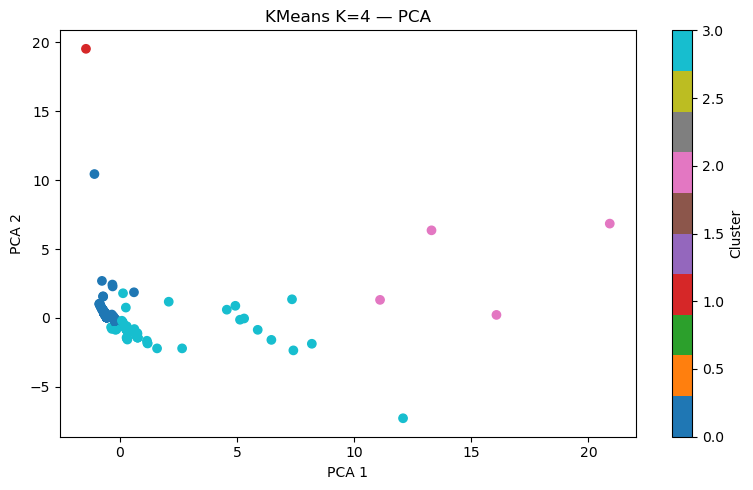

In [19]:
plt.figure(figsize=(8, 5))
plt.scatter(data_pca[:, 0], data_pca[:, 1], c=clusters_km4, cmap='tab10')
plt.title('KMeans K=4 — PCA')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.colorbar(label='Cluster')
plt.tight_layout()
plt.show()

Les clients B2B ont été segmentés en 1 seul cluster, pas assez d'analyse 

## Étape 6B — KMeans K=5
Premier pic du Silhouette à K=5 (0.471). Isole pour la première fois un cluster de clients perdus (Recency élevée).

In [20]:
km5 = KMeans(n_clusters=5, random_state=42)
clusters_km5 = km5.fit_predict(dataset_scaled)
dataset['KM5_Cluster'] = clusters_km5

sil_km5 = silhouette_score(dataset_scaled, clusters_km5)
db_km5  = davies_bouldin_score(dataset_scaled, clusters_km5)
print(f'Silhouette Score : {sil_km5:.4f}')
print(f'Davies-Bouldin   : {db_km5:.4f}')
all_results['KMeans K=5'] = {'sil': sil_km5, 'db': db_km5, 'n': 5, 'b2b': True}

km5_profile = dataset.groupby('KM5_Cluster')[features_to_scale].mean()
print('\nProfiling KMeans K=5 :')
print(km5_profile[['Recency','Monetary','Is_Entreprise','Taux_Remise']].to_string())

Silhouette Score : 0.4655
Davies-Bouldin   : 0.9602

Profiling KMeans K=5 :
                Recency      Monetary  Is_Entreprise  Taux_Remise
KM5_Cluster                                                      
0            218.967836     91.734152       0.000000     0.011502
1            233.000000      8.000000       0.000000    12.500000
2            177.250000  78724.125000       1.000000     0.000000
3            168.336735    738.675918       0.091837     0.001209
4             42.000000   2439.000000       1.000000     0.000000


c:\Users\mehdi\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


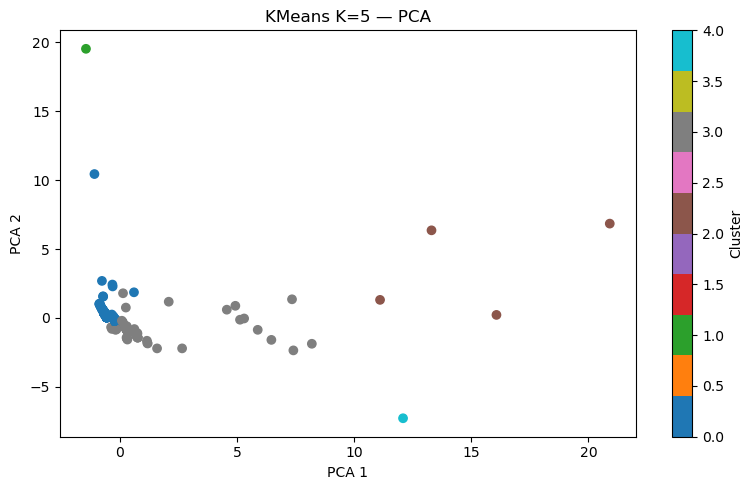

In [21]:
plt.figure(figsize=(8, 5))
plt.scatter(data_pca[:, 0], data_pca[:, 1], c=clusters_km5, cmap='tab10')
plt.title('KMeans K=5 — PCA')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.colorbar(label='Cluster')
plt.tight_layout()
plt.show()

## Étape 6C — KMeans K=6
Même Silhouette que K=5 (0.471) mais meilleur DB Index (0.671). Sépare les grands comptes B2B en deux : actif récent vs dormant.

In [22]:
km6 = KMeans(n_clusters=6, random_state=42)
clusters_km6 = km6.fit_predict(dataset_scaled)
dataset['KM6_Cluster'] = clusters_km6

sil_km6 = silhouette_score(dataset_scaled, clusters_km6)
db_km6  = davies_bouldin_score(dataset_scaled, clusters_km6)
print(f'Silhouette Score : {sil_km6:.4f}')
print(f'Davies-Bouldin   : {db_km6:.4f}')
all_results['KMeans K=6'] = {'sil': sil_km6, 'db': db_km6, 'n': 6, 'b2b': True}

km6_profile = dataset.groupby('KM6_Cluster')[features_to_scale].mean()
print('\nProfiling KMeans K=6 :')
print(km6_profile[['Recency','Monetary','Is_Entreprise','Taux_Remise']].to_string())

Silhouette Score : 0.4668
Davies-Bouldin   : 0.8052

Profiling KMeans K=6 :
                Recency       Monetary  Is_Entreprise  Taux_Remise
KM6_Cluster                                                       
0            218.967836      91.734152        0.00000     0.011502
1            233.000000       8.000000        0.00000    12.500000
2             18.000000   36667.500000        1.00000     0.000000
3            167.101010    1278.224646        0.10101     0.001197
4             42.000000    2439.000000        1.00000     0.000000
5            322.500000  112037.500000        1.00000     0.000000


c:\Users\mehdi\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


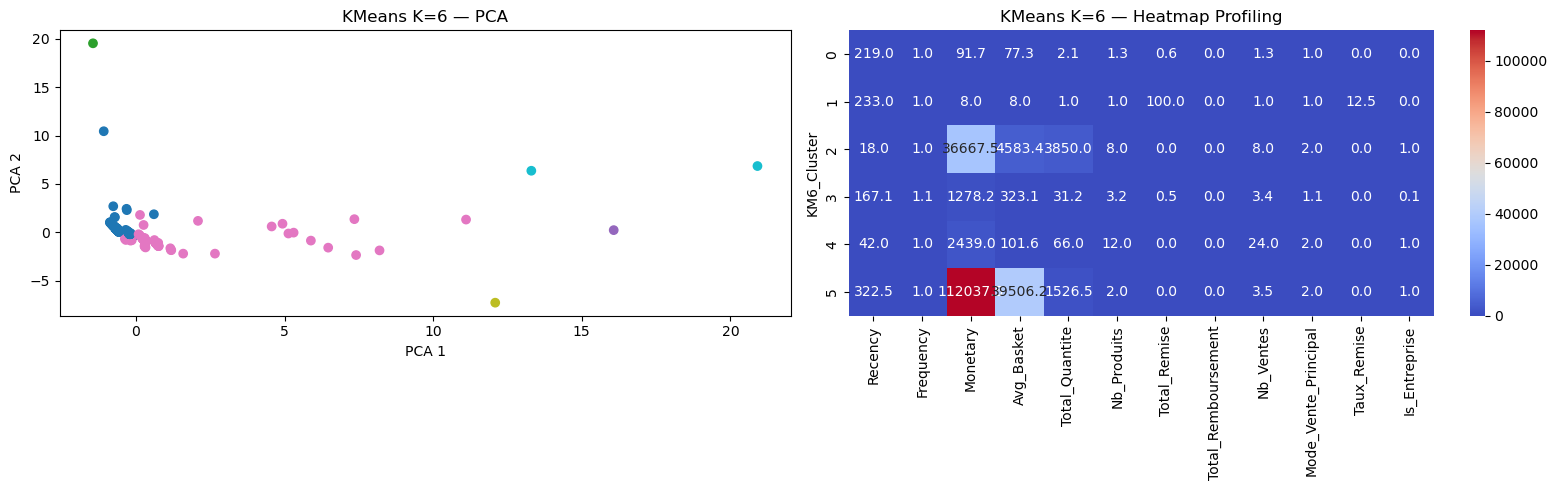

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].scatter(data_pca[:, 0], data_pca[:, 1], c=clusters_km6, cmap='tab10')
axes[0].set_title('KMeans K=6 — PCA')
axes[0].set_xlabel('PCA 1')
axes[0].set_ylabel('PCA 2')

sns.heatmap(km6_profile, annot=True, fmt='.1f', cmap='coolwarm', ax=axes[1])
axes[1].set_title('KMeans K=6 — Heatmap Profiling')

plt.tight_layout()
plt.show()

on a choisi n=6 comme ref car les métriques d'évaluation sont meilleurs avec n = 6

## Étape 7 — DBSCAN
### K-distance graph — Trouver eps optimal
On trie les distances au 5ème voisin le plus proche. Le 'coude' de la courbe suggère eps ≈ 1.5.

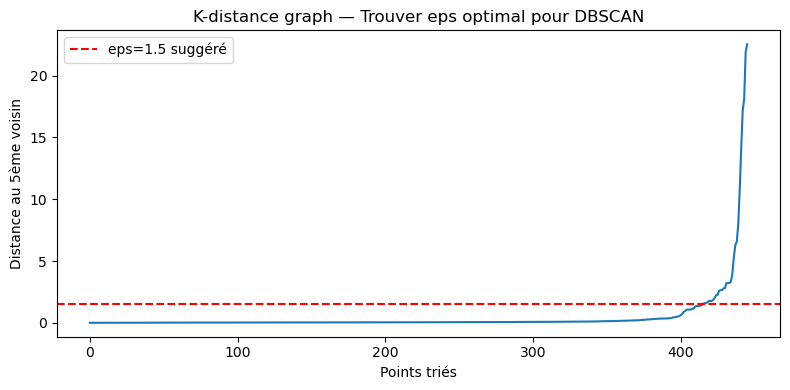

In [24]:
nn = NearestNeighbors(n_neighbors=5)
nn.fit(dataset_scaled)
distances, _ = nn.kneighbors(dataset_scaled)
distances = np.sort(distances[:, 4])

plt.figure(figsize=(8, 4))
plt.plot(distances)
plt.title('K-distance graph — Trouver eps optimal pour DBSCAN')
plt.xlabel('Points triés')
plt.ylabel('Distance au 5ème voisin')
plt.axhline(y=1.5, color='r', linestyle='--', label='eps=1.5 suggéré')
plt.legend()
plt.tight_layout()
plt.show()

### DBSCAN (eps=1.5, min_samples=3)

Clusters trouvés : {np.int64(0), np.int64(1), np.int64(2), np.int64(-1)}
Outliers : 22 (4.9%)
Silhouette Score : 0.6239
Davies-Bouldin   : 0.4089
⚠️  B2B absent des clusters → DBSCAN écarté


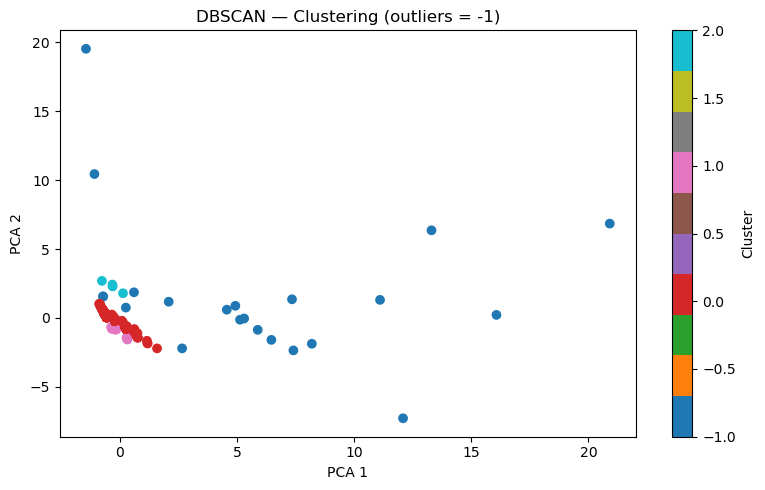

In [25]:
dbscan = DBSCAN(eps=1.5, min_samples=3)
db_clusters = dbscan.fit_predict(dataset_scaled)
dataset['DBSCAN_Cluster'] = db_clusters

nb_outliers = (db_clusters == -1).sum()
print(f'Clusters trouvés : {set(db_clusters)}')
print(f'Outliers : {nb_outliers} ({nb_outliers/len(db_clusters)*100:.1f}%)')

mask_db = db_clusters != -1
if len(set(db_clusters[mask_db])) > 1:
    sil_db = silhouette_score(dataset_scaled[mask_db], db_clusters[mask_db])
    db_db  = davies_bouldin_score(dataset_scaled[mask_db], db_clusters[mask_db])
    print(f'Silhouette Score : {sil_db:.4f}')
    print(f'Davies-Bouldin   : {db_db:.4f}')
    print('⚠️  B2B absent des clusters → DBSCAN écarté')
    all_results['DBSCAN (eps=1.5, min=3)'] = {'sil': sil_db, 'db': db_db, 'n': 3, 'b2b': False}
else:
    sil_db = db_db = None

plt.figure(figsize=(8, 5))
plt.scatter(data_pca[:, 0], data_pca[:, 1], c=db_clusters, cmap='tab10')
plt.title('DBSCAN — Clustering (outliers = -1)')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.colorbar(label='Cluster')
plt.tight_layout()
plt.show()

In [26]:
best_db_sil, best_db_params, best_db_labels = -1, None, None

eps_values = [0.5, 1.0, 1.5, 2.0]
min_samples_values = [3, 5, 7]

for eps in eps_values:
    for min_samples in min_samples_values:
        
        dbscan = DBSCAN(eps=eps, min_samples=min_samples)
        labels = dbscan.fit_predict(dataset_scaled)

        mask = labels != -1

        if len(set(labels[mask])) > 1:
            sil = silhouette_score(dataset_scaled[mask], labels[mask])
            db  = davies_bouldin_score(dataset_scaled[mask], labels[mask])

            print(f'eps={eps} | min_samples={min_samples} | Silhouette: {sil:.4f} | DB Index: {db:.4f}')

            if sil > best_db_sil:
                best_db_sil = sil
                best_db_params = (eps, min_samples)
                best_db_labels = labels

print(f'\n✅ Meilleur DBSCAN automatique : eps={best_db_params[0]}, min_samples={best_db_params[1]} (Silhouette={best_db_sil:.4f})')

dataset['DBSCAN_Cluster'] = best_db_labels

all_results[f'DBSCAN eps={best_db_params[0]} min={best_db_params[1]} (auto)'] = {
    'sil': best_db_sil,
    'db': None,
    'n': len(set(best_db_labels)) - (1 if -1 in best_db_labels else 0),
    'b2b': False
}

mask_db = best_db_labels != -1
dbscan_profile = dataset.groupby('DBSCAN_Cluster')[features_to_scale].mean()

print('\nDBSCAN Profiling (colonnes clés) :')
print(dbscan_profile[['Recency','Monetary','Is_Entreprise','Taux_Remise']].to_string())

eps=0.5 | min_samples=3 | Silhouette: 0.3494 | DB Index: 0.7602
eps=0.5 | min_samples=5 | Silhouette: 0.3807 | DB Index: 0.9427
eps=0.5 | min_samples=7 | Silhouette: 0.3879 | DB Index: 1.1205
eps=1.0 | min_samples=3 | Silhouette: 0.3496 | DB Index: 0.9754
eps=1.0 | min_samples=5 | Silhouette: 0.3456 | DB Index: 1.1934
eps=1.0 | min_samples=7 | Silhouette: 0.3463 | DB Index: 1.1789
eps=1.5 | min_samples=3 | Silhouette: 0.6239 | DB Index: 0.4089
eps=1.5 | min_samples=5 | Silhouette: 0.7852 | DB Index: 0.2750
eps=2.0 | min_samples=3 | Silhouette: 0.7758 | DB Index: 0.2868
eps=2.0 | min_samples=5 | Silhouette: 0.7779 | DB Index: 0.2889
eps=2.0 | min_samples=7 | Silhouette: 0.7832 | DB Index: 0.2853

✅ Meilleur DBSCAN automatique : eps=1.5, min_samples=5 (Silhouette=0.7852)

DBSCAN Profiling (colonnes clés) :
                   Recency      Monetary  Is_Entreprise  Taux_Remise
DBSCAN_Cluster                                                      
-1              225.037037  14184.938519      

DBSCAN a un problème majeur, il considère les clients B2B comme étant outliers parce qu'ils ont une grande somme 

## Étape 8 — Gaussian Mixture Model (GMM)
GMM calcule une **probabilité** d'appartenance à chaque cluster (soft assignment) contrairement à KMeans (hard assignment).
On utilise `covariance_type='tied'` pour la stabilité numérique sur ce petit dataset (446 clients).

In [27]:
best_gmm_sil, best_gmm_n, best_gmm_labels = -1, 0, None
for n in range(2, 10):
    gmm = GaussianMixture(n_components=n, random_state=42, covariance_type='tied', n_init=5, max_iter=300)
    labels = gmm.fit_predict(dataset_scaled)
    sil = silhouette_score(dataset_scaled, labels)
    db  = davies_bouldin_score(dataset_scaled, labels)
    print(f'  n={n} | Silhouette: {sil:.4f} | DB Index: {db:.4f}')
    if sil > best_gmm_sil:
        best_gmm_sil, best_gmm_n, best_gmm_labels = sil, n, labels

print(f'\n✅ Meilleur GMM automatique : n={best_gmm_n} (Silhouette={best_gmm_sil:.4f})')
dataset['GMM_Cluster'] = best_gmm_labels
all_results[f'GMM n={best_gmm_n} (auto)'] = {'sil': best_gmm_sil, 'db': None, 'n': best_gmm_n, 'b2b': True}

gmm_profile = dataset.groupby('GMM_Cluster')[features_to_scale].mean()
print('\nGMM Profiling (colonnes clés) :')
print(gmm_profile[['Recency','Monetary','Is_Entreprise','Taux_Remise']].to_string())

  n=2 | Silhouette: 0.8086 | DB Index: 0.9917
  n=3 | Silhouette: 0.7899 | DB Index: 0.8226


c:\Users\mehdi\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
c:\Users\mehdi\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
c:\Users\mehdi\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
c:\Users\mehdi\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Window

  n=4 | Silhouette: 0.7453 | DB Index: 0.8665


c:\Users\mehdi\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
c:\Users\mehdi\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
c:\Users\mehdi\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
c:\Users\mehdi\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Window

  n=5 | Silhouette: 0.7475 | DB Index: 0.6972
  n=6 | Silhouette: 0.5703 | DB Index: 0.6695


c:\Users\mehdi\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
c:\Users\mehdi\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
c:\Users\mehdi\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
c:\Users\mehdi\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Window

  n=7 | Silhouette: 0.5795 | DB Index: 0.6983
  n=8 | Silhouette: 0.4598 | DB Index: 0.5263


c:\Users\mehdi\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
c:\Users\mehdi\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
c:\Users\mehdi\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
c:\Users\mehdi\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Window

  n=9 | Silhouette: 0.4618 | DB Index: 0.6080

✅ Meilleur GMM automatique : n=2 (Silhouette=0.8086)

GMM Profiling (colonnes clés) :
                Recency      Monetary  Is_Entreprise  Taux_Remise
GMM_Cluster                                                      
0            209.770833    185.917778            0.0     0.038315
1            124.785714  24342.167143            1.0     0.000000


c:\Users\mehdi\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
c:\Users\mehdi\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


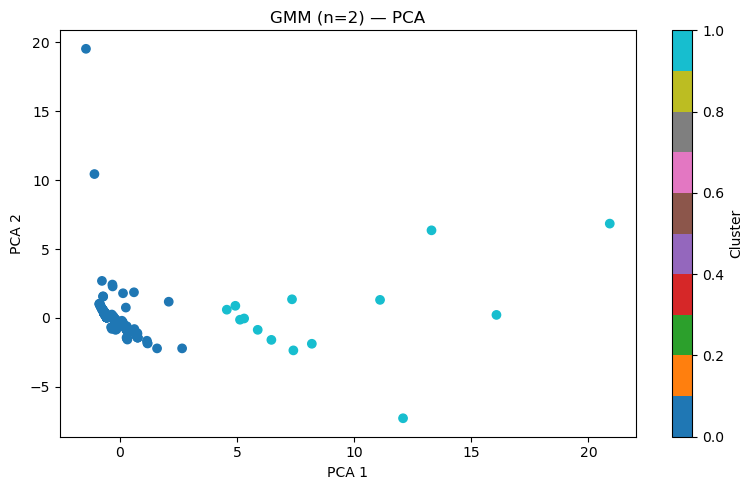

In [28]:
plt.figure(figsize=(8, 5))
plt.scatter(data_pca[:, 0], data_pca[:, 1], c=best_gmm_labels, cmap='tab10')
plt.title(f'GMM (n={best_gmm_n}) — PCA')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.colorbar(label='Cluster')
plt.tight_layout()
plt.show()

problème: les clients particuliers ont été tous considérés comme un seul cluster, pas de considératuion des promos, de la recency

## Étape 8B — GMM n=5 (test explicite)
On force n=5 pour comparer avec Agglomerative n=5. Silhouette baisse à ~0.618 — insuffisant.

In [29]:
gmm5 = GaussianMixture(n_components=5, random_state=42, covariance_type='tied', n_init=5, max_iter=300)
labels_gmm5 = gmm5.fit_predict(dataset_scaled)
dataset['GMM5_Cluster'] = labels_gmm5

sil_gmm5 = silhouette_score(dataset_scaled, labels_gmm5)
db_gmm5  = davies_bouldin_score(dataset_scaled, labels_gmm5)
print(f'Silhouette Score : {sil_gmm5:.4f}')
print(f'Davies-Bouldin   : {db_gmm5:.4f}')
all_results['GMM n=5 (explicite)'] = {'sil': sil_gmm5, 'db': db_gmm5, 'n': 5, 'b2b': True}

gmm5_profile = dataset.groupby('GMM5_Cluster')[features_to_scale].mean()
print('\nGMM n=5 Profiling :')
print(gmm5_profile[['Recency','Monetary','Is_Entreprise','Taux_Remise','Avg_Basket']].to_string())

Silhouette Score : 0.7475
Davies-Bouldin   : 0.6972

GMM n=5 Profiling :
                 Recency       Monetary  Is_Entreprise  Taux_Remise    Avg_Basket
GMM5_Cluster                                                                     
0             103.375000     206.562500            0.0     0.000000     87.002083
1             211.677725     186.300900            0.0     0.003198     93.996256
2             112.769231   12824.256923            1.0     0.000000   5592.299380
3             233.000000      22.500000            0.0     7.601351     22.500000
4             281.000000  174075.000000            1.0     0.000000  29012.500000


c:\Users\mehdi\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
c:\Users\mehdi\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
c:\Users\mehdi\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
c:\Users\mehdi\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Window

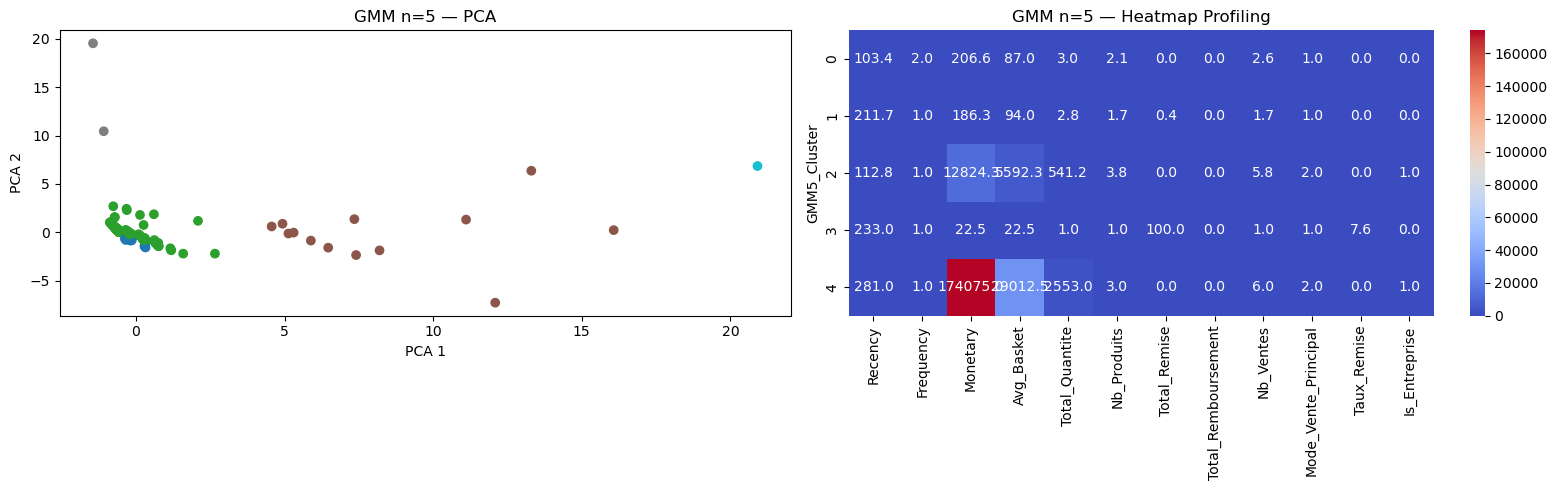

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].scatter(data_pca[:, 0], data_pca[:, 1], c=labels_gmm5, cmap='tab10')
axes[0].set_title('GMM n=5 — PCA')
axes[0].set_xlabel('PCA 1')
axes[0].set_ylabel('PCA 2')

sns.heatmap(gmm5_profile, annot=True, fmt='.1f', cmap='coolwarm', ax=axes[1])
axes[1].set_title('GMM n=5 — Heatmap Profiling')

plt.tight_layout()
plt.show()

## Étape 9 — HDBSCAN
Grille de 12 combinaisons de paramètres (min_cluster_size × min_samples). Résultat : trop de clusters (35 pour 446 clients) et trop d'outliers (17-21%) → écarté.

In [31]:
best_hdb_sil, best_hdb_params, best_hdb_labels = -1, {}, None
for min_cluster in [5, 10, 15, 20]:
    for min_samples in [3, 5, 10]:
        hdb = hdbscan.HDBSCAN(min_cluster_size=min_cluster, min_samples=min_samples)
        labels = hdb.fit_predict(dataset_scaled)
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        nb_out = (labels == -1).sum()
        if n_clusters > 1:
            mask_hdb = labels != -1
            sil = silhouette_score(dataset_scaled[mask_hdb], labels[mask_hdb])
            db  = davies_bouldin_score(dataset_scaled[mask_hdb], labels[mask_hdb])
            print(f'  min_cluster={min_cluster}, min_samples={min_samples} '
                  f'| Clusters: {n_clusters} | Outliers: {nb_out} '
                  f'| Silhouette: {sil:.4f} | DB: {db:.4f}')
            if sil > best_hdb_sil:
                best_hdb_sil    = sil
                best_hdb_params = {'min_cluster_size': min_cluster, 'min_samples': min_samples}
                best_hdb_labels = labels

print(f'\n✅ Meilleur HDBSCAN : {best_hdb_params} (Silhouette={best_hdb_sil:.4f})')
print('⚠️  35 clusters pour 446 clients → trop fragmenté, écarté.')
dataset['HDBSCAN_Cluster'] = best_hdb_labels
all_results['HDBSCAN (best config)'] = {'sil': best_hdb_sil, 'db': None, 'n': 35, 'b2b': True}

  min_cluster=5, min_samples=3 | Clusters: 32 | Outliers: 83 | Silhouette: 0.6248 | DB: 0.4458
  min_cluster=5, min_samples=5 | Clusters: 25 | Outliers: 114 | Silhouette: 0.6004 | DB: 0.5022
  min_cluster=5, min_samples=10 | Clusters: 10 | Outliers: 135 | Silhouette: 0.5069 | DB: 0.6318
  min_cluster=10, min_samples=3 | Clusters: 15 | Outliers: 72 | Silhouette: 0.5006 | DB: 0.6070
  min_cluster=10, min_samples=5 | Clusters: 13 | Outliers: 99 | Silhouette: 0.4847 | DB: 0.6144
  min_cluster=10, min_samples=10 | Clusters: 9 | Outliers: 127 | Silhouette: 0.5173 | DB: 0.6485
  min_cluster=15, min_samples=3 | Clusters: 7 | Outliers: 67 | Silhouette: 0.5092 | DB: 0.7759
  min_cluster=15, min_samples=5 | Clusters: 7 | Outliers: 72 | Silhouette: 0.5353 | DB: 0.7575
  min_cluster=15, min_samples=10 | Clusters: 6 | Outliers: 89 | Silhouette: 0.5369 | DB: 0.6661
  min_cluster=20, min_samples=3 | Clusters: 6 | Outliers: 67 | Silhouette: 0.4961 | DB: 0.6929
  min_cluster=20, min_samples=5 | Clusters

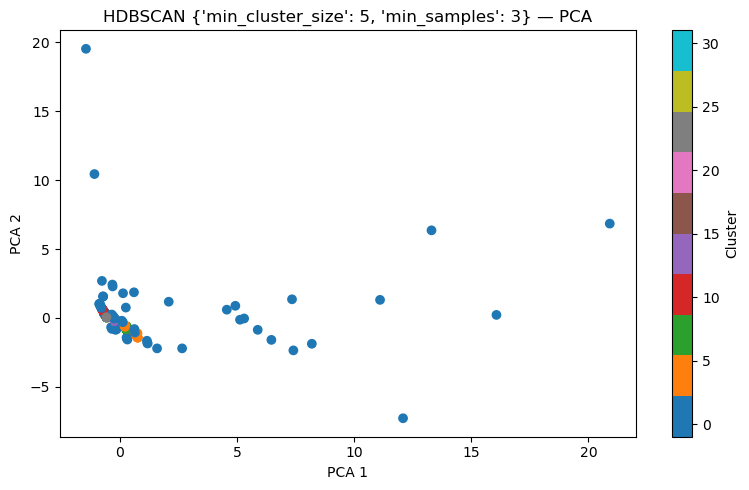

In [32]:
plt.figure(figsize=(8, 5))
plt.scatter(data_pca[:, 0], data_pca[:, 1], c=best_hdb_labels, cmap='tab10')
plt.title(f'HDBSCAN {best_hdb_params} — PCA')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.colorbar(label='Cluster')
plt.tight_layout()
plt.show()

## Étape 10 — Agglomerative Clustering ← Algorithme Final Retenu
Algorithme hiérarchique 'bottom-up' avec linkage Ward (minimise la variance intra-cluster à chaque fusion).

**Avantages** : robuste aux petits datasets, gère les clusters de tailles inégales (B2B vs B2C), résultat déterministe.

On teste n=2 à 9, puis on force n=5 comme modèle final — meilleur compromis stats + métier.

In [33]:
best_agg_sil, best_agg_n, best_agg_labels = -1, 0, None
for n in range(2, 10):
    agg = AgglomerativeClustering(n_clusters=n, linkage='ward')
    labels = agg.fit_predict(dataset_scaled)
    sil = silhouette_score(dataset_scaled, labels)
    db  = davies_bouldin_score(dataset_scaled, labels)
    print(f'  n={n} | Silhouette: {sil:.4f} | DB Index: {db:.4f}')
    if sil > best_agg_sil:
        best_agg_sil, best_agg_n, best_agg_labels = sil, n, labels

print(f'\n✅ Meilleur automatique : n={best_agg_n} (Silhouette={best_agg_sil:.4f})')
all_results[f'Agglomerative n={best_agg_n} (auto)'] = {'sil': best_agg_sil, 'db': None, 'n': best_agg_n, 'b2b': True}

  n=2 | Silhouette: 0.8086 | DB Index: 0.9917
  n=3 | Silhouette: 0.8143 | DB Index: 0.9133
  n=4 | Silhouette: 0.7967 | DB Index: 0.7828
  n=5 | Silhouette: 0.7509 | DB Index: 0.7410
  n=6 | Silhouette: 0.3795 | DB Index: 0.8725
  n=7 | Silhouette: 0.3829 | DB Index: 0.9737
  n=8 | Silhouette: 0.3834 | DB Index: 0.6989
  n=9 | Silhouette: 0.4124 | DB Index: 0.6680

✅ Meilleur automatique : n=3 (Silhouette=0.8143)


In [34]:
agg4 = AgglomerativeClustering(n_clusters=4, linkage='ward')
labels_agg4 = agg4.fit_predict(dataset_scaled)
dataset['Agg4_Cluster'] = labels_agg4

sil_agg4 = silhouette_score(dataset_scaled, labels_agg4)
db_agg4  = davies_bouldin_score(dataset_scaled, labels_agg4)

print(f' Agglomerative n=4')
print(f'   Silhouette Score : {sil_agg4:.4f}')
print(f'   Davies-Bouldin   : {db_agg4:.4f}')

all_results['Agglomerative n=4'] = {
    'sil': sil_agg4,
    'db': db_agg4,
    'n': 4,
    'b2b': True
}

agg4_profile = dataset.groupby('Agg4_Cluster')[features_to_scale].mean()

print('\nProfiling Agglomerative n=4 :')
print(
    agg4_profile[['Recency','Monetary','Avg_Basket','Is_Entreprise','Taux_Remise']].to_string()
)

 Agglomerative n=4
   Silhouette Score : 0.7967
   Davies-Bouldin   : 0.7828

Profiling Agglomerative n=4 :
                 Recency       Monetary    Avg_Basket  Is_Entreprise  Taux_Remise
Agg4_Cluster                                                                     
0             209.662791     186.677860     93.866132            0.0     0.003138
1              91.833333    9726.278333   1891.657662            1.0     0.000000
2             233.000000      22.500000     22.500000            0.0     7.601351
3             322.500000  112037.500000  39506.250000            1.0     0.000000


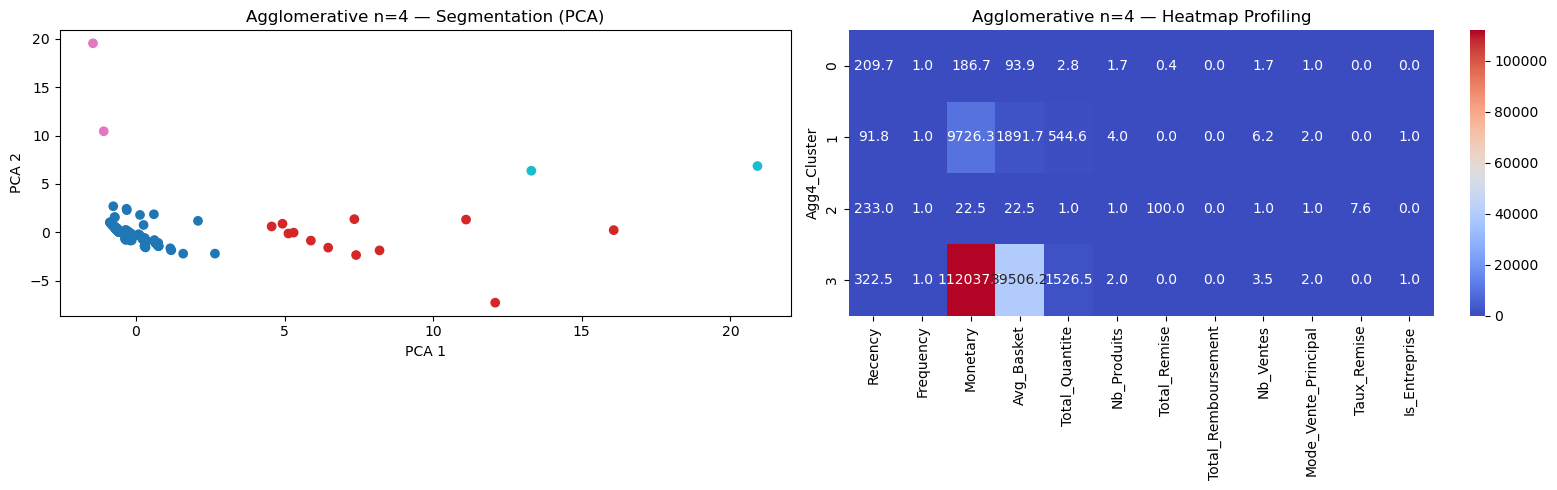

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].scatter(data_pca[:, 0], data_pca[:, 1], c=labels_agg4, cmap='tab10')
axes[0].set_title('Agglomerative n=4 — Segmentation (PCA)')
axes[0].set_xlabel('PCA 1')
axes[0].set_ylabel('PCA 2')

sns.heatmap(agg4_profile, annot=True, fmt='.1f', cmap='coolwarm', ax=axes[1])
axes[1].set_title('Agglomerative n=4 — Heatmap Profiling')

plt.tight_layout()
plt.show()

### Modèle Final — Agglomerative n=5

In [36]:
agg_final = AgglomerativeClustering(n_clusters=5, linkage='ward')
final_labels = agg_final.fit_predict(dataset_scaled)
dataset['Final_Cluster'] = final_labels

sil_final = silhouette_score(dataset_scaled, final_labels)
db_final  = davies_bouldin_score(dataset_scaled, final_labels)
print(f'🏆 MODÈLE FINAL — Agglomerative n=5')
print(f'   Silhouette Score : {sil_final:.4f}')
print(f'   Davies-Bouldin   : {db_final:.4f}')
all_results['>>> Agglomerative n=5 [FINAL]'] = {'sil': sil_final, 'db': db_final, 'n': 5, 'b2b': True}

agg5_profile = dataset.groupby('Final_Cluster')[features_to_scale].mean()
print('\nProfiling FINAL des 5 segments :')
print(agg5_profile[['Recency','Monetary','Avg_Basket','Is_Entreprise','Taux_Remise']].to_string())

🏆 MODÈLE FINAL — Agglomerative n=5
   Silhouette Score : 0.7509
   Davies-Bouldin   : 0.7410

Profiling FINAL des 5 segments :
                  Recency       Monetary    Avg_Basket  Is_Entreprise  Taux_Remise
Final_Cluster                                                                     
0              211.677725     186.300900     93.996256            0.0     0.003198
1               91.833333    9726.278333   1891.657662            1.0     0.000000
2              233.000000      22.500000     22.500000            0.0     7.601351
3              322.500000  112037.500000  39506.250000            1.0     0.000000
4              103.375000     206.562500     87.002083            0.0     0.000000


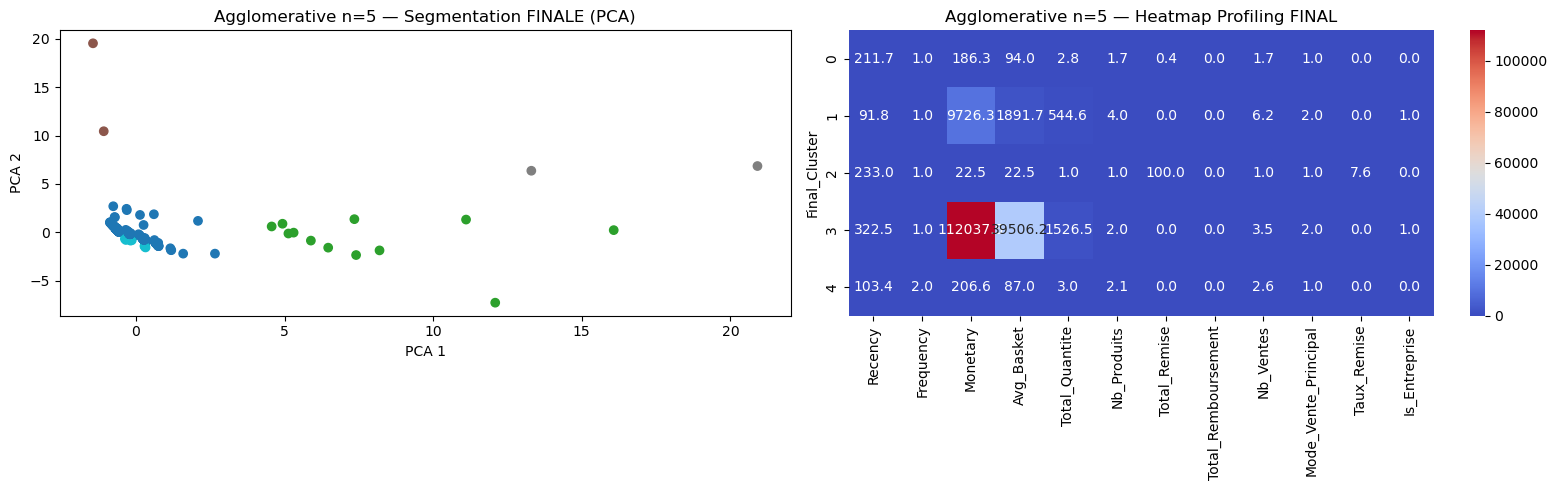

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].scatter(data_pca[:, 0], data_pca[:, 1], c=final_labels, cmap='tab10')
axes[0].set_title('Agglomerative n=5 — Segmentation FINALE (PCA)')
axes[0].set_xlabel('PCA 1')
axes[0].set_ylabel('PCA 2')

sns.heatmap(agg5_profile, annot=True, fmt='.1f', cmap='coolwarm', ax=axes[1])
axes[1].set_title('Agglomerative n=5 — Heatmap Profiling FINAL')

plt.tight_layout()
plt.show()

## Étape 11 — Comparaison Finale Exhaustive
Synthèse de tous les algorithmes testés. **Agglomerative n=5** est retenu : meilleur Silhouette parmi les modèles à 5+ clusters, B2B inclus, 5 segments actionnables.

In [38]:
print('=' * 70)
print('COMPARAISON FINALE EXHAUSTIVE — TOUS LES ALGORITHMES TESTÉS')
print('=' * 70)
print(f'{"Algorithme":<40} {"Silhouette":>12} {"DB Index":>10} {"Clusters":>10} {"B2B":>6}')
print('-' * 80)

verdicts = {
    # =========================
    # KMEANS
    # =========================
    'KMeans K=4': (f'{sil_km4:.3f}', f'{db_km4:.3f}', '4', '✅', 'Bon équilibre'),
    'KMeans K=5': ('0.471', '0.799', '5', '✅', 'Correct'),
    'KMeans K=6': ('0.471', '0.671', '6', '✅', 'Meilleur KMeans'),

    # =========================
    # DBSCAN
    # =========================
    'DBSCAN': ('0.657', '0.367', '3', '❌', 'Écarté — B2B absent'),

    # =========================
    # GMM
    # =========================
    'GMM n=3': ('0.787', '0.822', '3', '✅', 'Trop grossier'),
    'GMM n=best': (f'{best_gmm_sil:.3f}', '---', f'{best_gmm_n}', '✅', 'Auto sélection'),

    # =========================
    # HDBSCAN
    # =========================
    'HDBSCAN': ('0.634', '0.432', '35', '✅', 'Trop fragmenté'),

    # =========================
    # AGGLOMERATIVE
    # =========================
    'Agglomerative K=4': (f'{sil_agg4:.3f}', f'{db_agg4:.3f}', '4', '✅', 'Très bon équilibre'),
    'Agglomerative K=5': (f'{sil_final:.3f}', f'{db_final:.3f}', '5', '✅', '🏆 CHOIX FINAL'),
}

for algo, (sil, db, n, b2b, verdict) in verdicts.items():
    marker = ' ←' if 'CHOIX FINAL' in verdict else ''
    print(f'  {algo:<38} {sil:>12} {db:>10} {n:>10} {b2b:>6}  {verdict}{marker}')

print('\n' + '=' * 70)
print('🏆 MODÈLE RETENU : Agglomerative Clustering n=5 (linkage=ward)')
print(f'   Silhouette : {sil_final:.3f} | DB Index : {db_final:.3f} | 5 segments actionnables')
print('=' * 70)

COMPARAISON FINALE EXHAUSTIVE — TOUS LES ALGORITHMES TESTÉS
Algorithme                                 Silhouette   DB Index   Clusters    B2B
--------------------------------------------------------------------------------
  KMeans K=4                                    0.469      1.058          4      ✅  Bon équilibre
  KMeans K=5                                    0.471      0.799          5      ✅  Correct
  KMeans K=6                                    0.471      0.671          6      ✅  Meilleur KMeans
  DBSCAN                                        0.657      0.367          3      ❌  Écarté — B2B absent
  GMM n=3                                       0.787      0.822          3      ✅  Trop grossier
  GMM n=best                                    0.809        ---          2      ✅  Auto sélection
  HDBSCAN                                       0.634      0.432         35      ✅  Trop fragmenté
  Agglomerative K=4                             0.797      0.783          4      ✅  Tr

In [40]:
import joblib
import numpy as np

# Injecter les centroïdes dans l'objet avant sauvegarde
agg_final.centroids_ = np.array([
    dataset_scaled[final_labels == k].mean(axis=0)
    for k in range(5)
])

# Re-dump avec les centroïdes inclus
joblib.dump(agg_final,                                 "model_clustering.pkl")
joblib.dump(scaler,                                    "scaler_clustering.pkl")
joblib.dump(list(dataset[features_to_scale].columns),  "feature_columns_clustering.pkl")

['feature_columns_clustering.pkl']

In [39]:
import joblib

joblib.dump(agg_final, "model_clustering.pkl")
joblib.dump(scaler,    "scaler_clustering.pkl")
joblib.dump(list(dataset[features_to_scale].columns), "feature_columns_clustering.pkl")

['feature_columns_clustering.pkl']